### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib           
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [2]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\MSFT.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,14.872976,14.924187,14.170662,14.287715,50084000
2009-01-05,15.011971,15.121707,14.675444,14.777866,61475200
2009-01-06,15.187551,15.363130,15.077815,15.180236,58083400
2009-01-07,14.273087,14.843718,14.251139,14.770560,72709900
2009-01-08,14.719351,14.770561,14.302350,14.360876,70255400


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [3]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [4]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [5]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [6]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [7]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

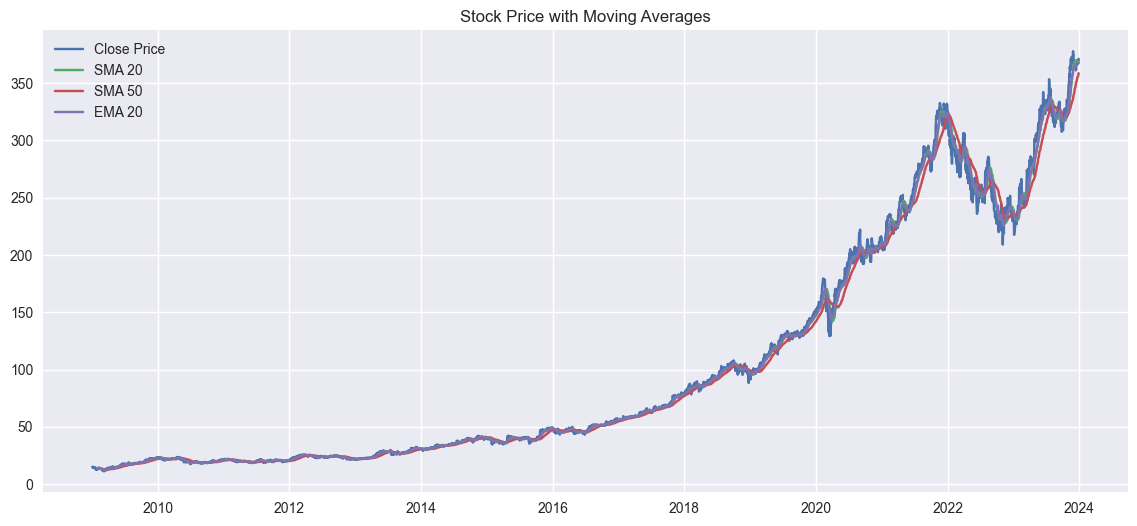

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

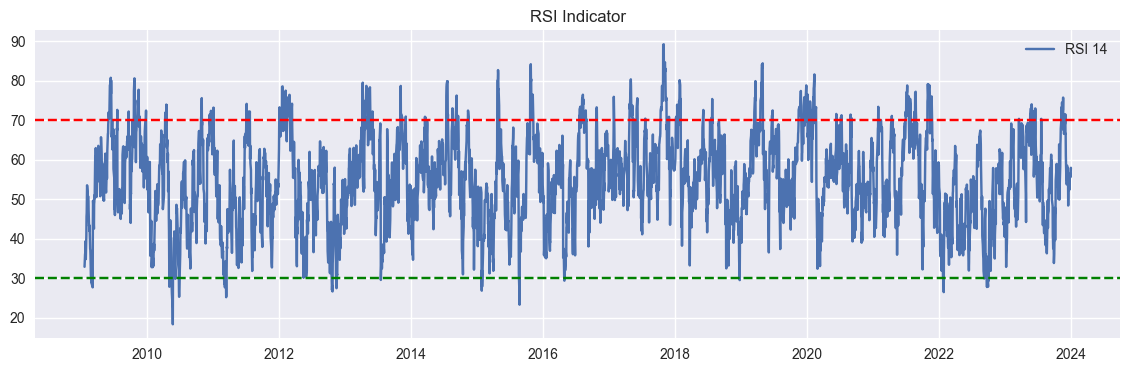

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

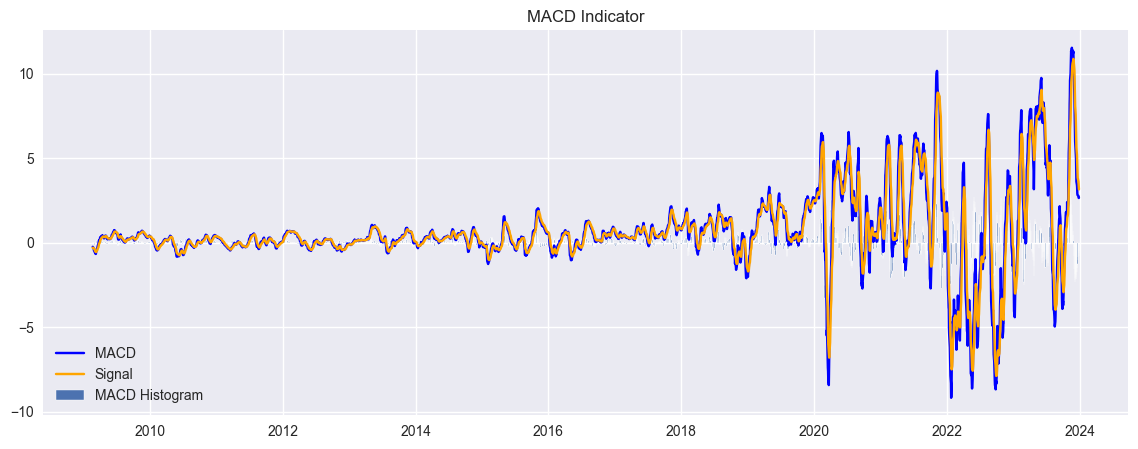

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

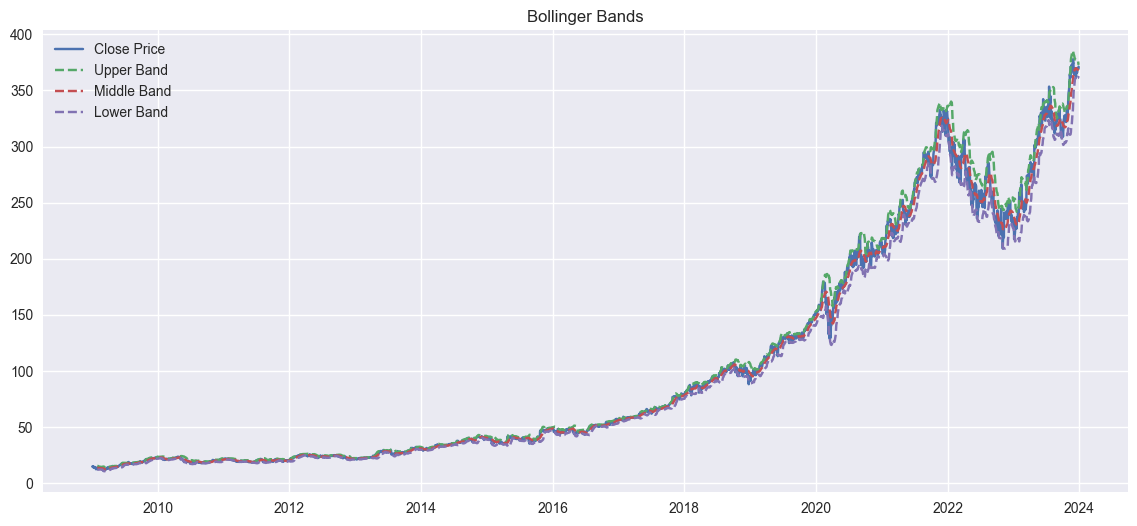

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std           min           25%  \
Close        3774.0  1.024587e+02  1.005300e+02  1.115939e+01  2.372356e+01   
High         3774.0  1.034408e+02  1.015274e+02  1.150559e+01  2.391467e+01   
Low          3774.0  1.013744e+02  9.943128e+01  1.095315e+01  2.349813e+01   
Open         3774.0  1.024208e+02  1.004968e+02  1.119622e+01  2.372139e+01   
Volume       3774.0  3.895754e+07  2.245626e+07  7.425600e+06  2.398462e+07   
SMA_20       3755.0  1.020087e+02  9.970924e+01  1.211550e+01  2.382039e+01   
SMA_50       3725.0  1.013069e+02  9.842951e+01  1.289480e+01  2.398732e+01   
EMA_20       3755.0  1.020116e+02  9.967472e+01  1.234149e+01  2.380424e+01   
RSI_14       3760.0  5.500441e+01  1.128716e+01  1.828338e+01  4.745296e+01   
MACD         3741.0  6.554724e-01  2.361843e+00 -9.182050e+00 -1.175607e-01   
MACD_signal  3741.0  6.517557e-01  2.212899e+00 -7.888239e+00 -9.272424e-02   
MACD_hist    3741.0  3.716790e-03  7.352411e-01 -3.6

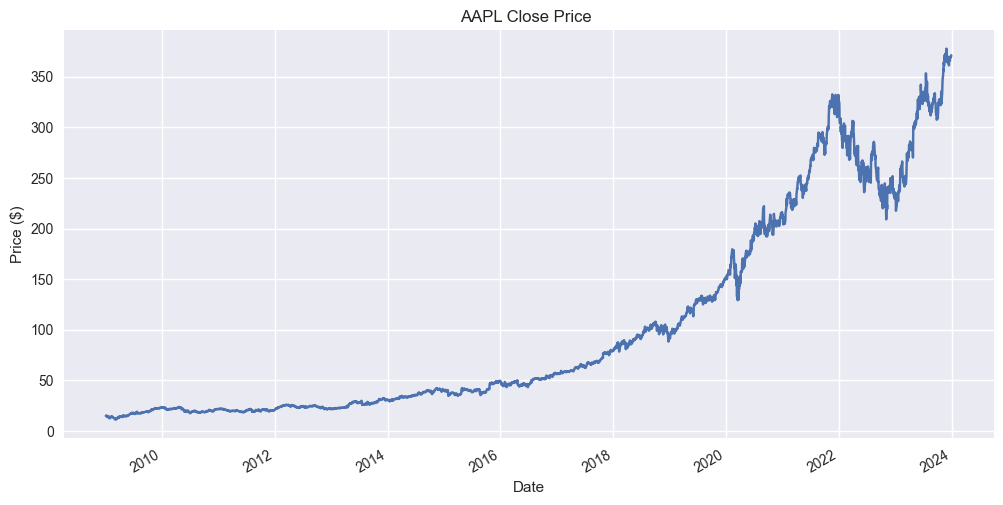

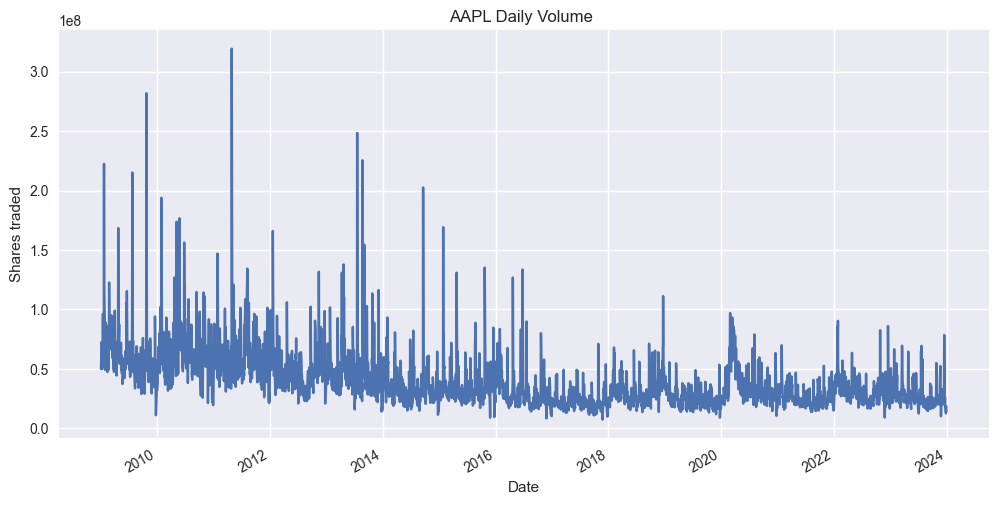

In [12]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [13]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,369.767883,370.360181,367.921911,368.879451,17107500,368.730389,355.078464,366.580145,56.363342,2.805416,3.840081,-1.034664,376.381103,368.730389,361.079676
2023-12-26,369.846832,372.097540,368.701731,370.182461,12673100,368.535426,356.018111,366.891259,56.447998,2.767033,3.625471,-0.858438,375.856574,368.535426,361.214278
2023-12-27,369.264465,370.241738,368.020642,368.889342,14905400,368.109468,356.849368,367.117278,55.591261,2.658971,3.432171,-0.773200,374.098950,368.109468,362.119987
2023-12-28,370.458862,371.623696,369.353256,370.547702,14327000,367.933260,357.715942,367.435524,57.031664,2.639285,3.273594,-0.634309,373.406273,367.933260,362.460247
2023-12-29,371.209198,372.314805,368.682088,371.169703,18730800,367.791606,358.635943,367.794922,57.954296,2.653640,3.149603,-0.495963,372.747004,367.791606,362.836208


### Price + SMA + Bollinger Bands

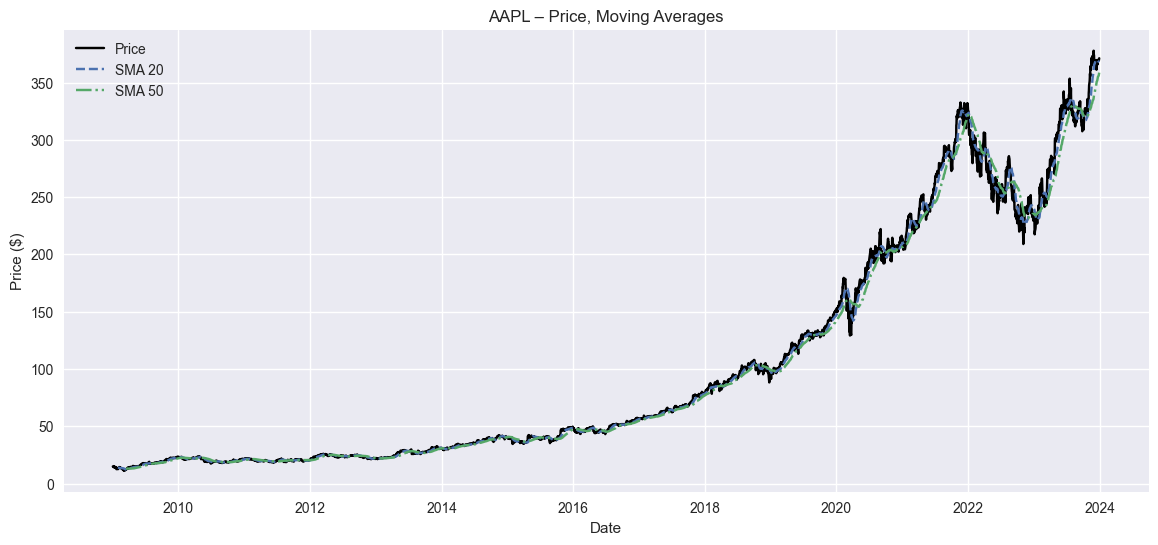

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

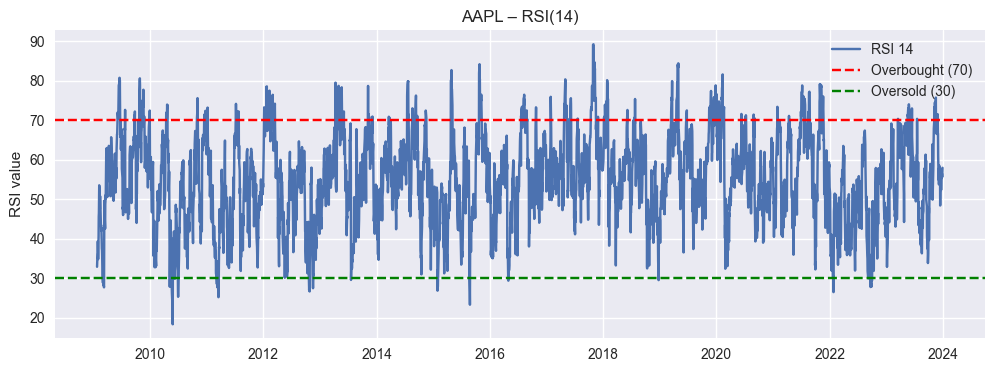

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

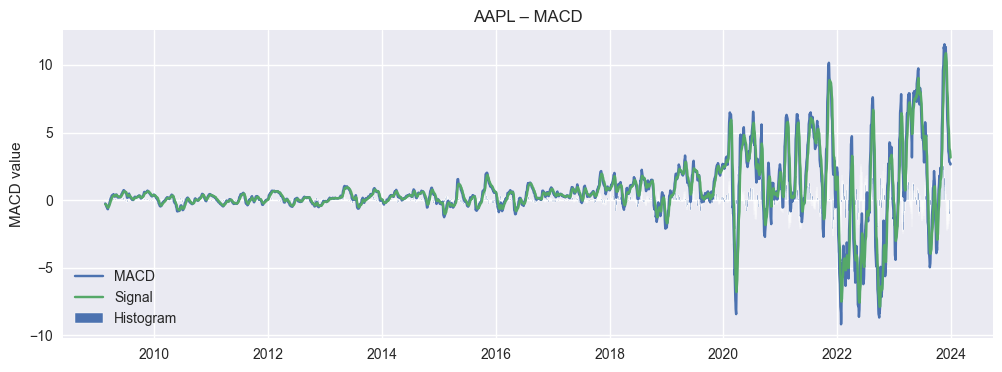

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
